# Statistical Distribution Analysis Model

## Import Data and Libraries

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import bernoulli, binom, poisson, lognorm, powerlaw, norm, zscore

from scipy.stats import boxcox
import statsmodels.api as sm

data= pd.read_csv('spread_locator_dataset.csv.csv')
data


,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4,North,Success
...,...,...,...,...,...,...,...
215,10c2a8f2-89d0-485c-bf8f-9508d32a02fc,CUST5563,4356.76,2023-01-12,2,South,Fail
216,5618814b-f7e2-424d-9617-9fc8d8643370,CUST8579,2025.53,2023-01-29,6,South,Fail
217,5636c9e7-9d54-4654-9c89-fdf31be87d96,CUST5092,2648.08,2023-01-30,1,West,Fail
218,6ba09450-a455-4983-bbad-3dad292cc839,CUST2235,2338.62,2023-01-26,3,North,Success


# 1. Fit the data to Bernoulli and Binomial distributions (transaction occurrence & weekly count).

## Bernoulli Distribution (Transaction Occurrence) We’ll use the transaction_status field (Success = 1, Fail = 0) to model whether a transaction occurred successfully. 

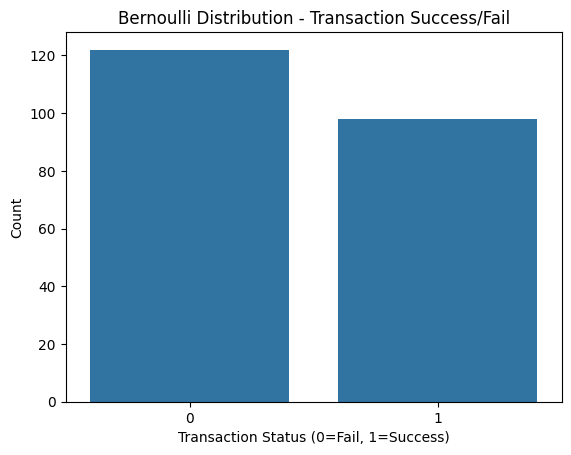

In [4]:
data["status_binary"] = data["transaction_status"].map({"Success":1, "Fail":0})

sns.countplot(x=data["status_binary"])
plt.title("Bernoulli Distribution - Transaction Success/Fail")
plt.xlabel("Transaction Status (0=Fail, 1=Success)")
plt.ylabel("Count")
plt.show()

### Interpretation:  
The Bernoulli chart shows that failed transactions (≈120) are slightly more frequent than successful ones (≈100).

## Binomial Distribution (Weekly Transaction Counts)

We’ll use the transaction_count field to model how many transactions a customer makes in a week.

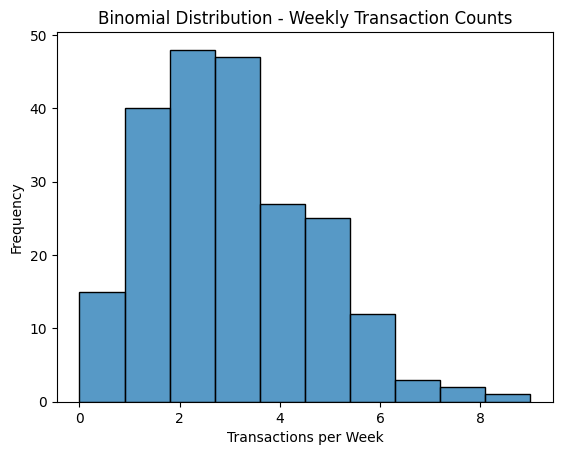

In [5]:
# --- 2. Binomial Distribution (Weekly Count) ---
sns.histplot(data["transaction_count"], bins=10, kde=False)
plt.title("Binomial Distribution - Weekly Transaction Counts")
plt.xlabel("Transactions per Week")
plt.ylabel("Frequency")
plt.show()

### Interpretation:  
Most customers transact 2–3 times weekly, while very high transaction counts are rare.

# 2. Fit the data to Poisson distribution (number of transactions per day).

Lamda: 7.096774193548387


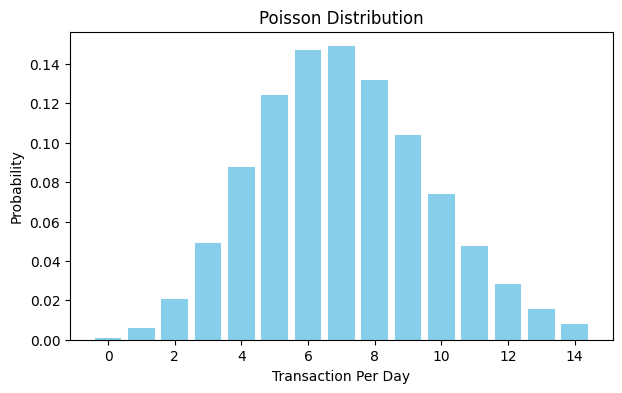

In [9]:
# Simulate multiple transactions per day
daily_transaction= data.groupby("transaction_date").size()

lam= daily_transaction.mean()
print("Lamda:",lam)

x= np.arange(0,daily_transaction.max()+3)

pmf=poisson.pmf(x,lam)

plt.figure(figsize=(7,4))
plt.bar(x,pmf,color='skyblue')
plt.title("Poisson Distribution")
plt.xlabel("Transaction Per Day")
plt.ylabel("Probability")
plt.show()


### Interpretation
- Most likely outcome: The peak around 6–7 transactions per day shows this is the most common number of daily transactions.

- Probability spread: Values lower or higher than 6–7 have decreasing probabilities, meaning extreme transaction counts are rare.

- Event modeling: This distribution is useful for modeling random events over time, like customer arrivals or system requests.

# 3. Model transaction amounts using Log-Normal and Power Law distributions.

## Log-Normal Distribution

Shape: 0.4749178350151927
Scale: 2983.1591334067753


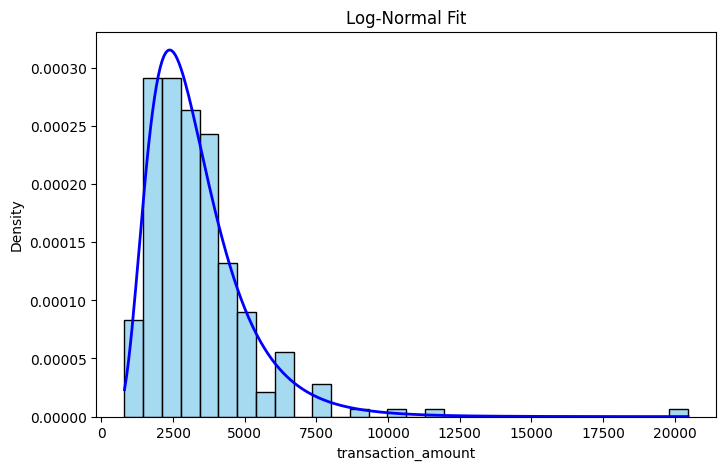

In [11]:
amt= data['transaction_amount']

shape, loc, scale = .fit(amt,floc=0)

print("Shape:",shape)
print("Scale:",scale)

plt.figure(figsize=(8,5))

sns.histplot(amt, bins=30, stat='density', color='skyblue')

x=np.linspace(amt.min(),amt.max(),300)

pdf= lognorm.pdf(x, shape, loc, scale)

plt.plot(x, pdf, 'b', linewidth=2)

plt.title("Log-Normal Fit")

plt.show()

### Interpretation
- Skewed distribution: Most transaction amounts cluster at lower values (around 2000–3000), while fewer but larger transactions stretch out into a long right tail.

- Log-normal fit: The smooth curve shows that transaction amounts follow a log-normal pattern, common in financial data where values can vary widely but remain positively skewed.

- Practical insight: This means small transactions are frequent, but occasional very large ones significantly influence overall behavior.

## Power-Law Distribution

Shape: 0.41232325172331613


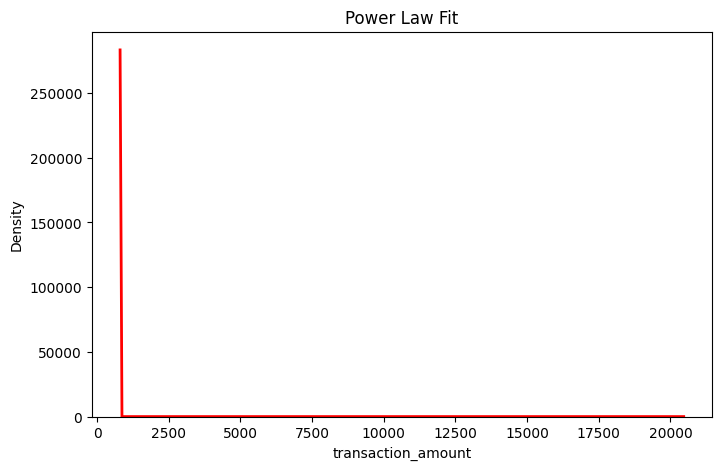

In [13]:
shape, loc, scale= powerlaw.fit(amt)
print("Shape:",shape)

pdf= powerlaw.pdf(x, shape, loc, scale)

plt.figure(figsize=(8,5))

sns.histplot(amt, bins=30, stat="density", color='blue')

plt.plot(x, pdf, 'red', linewidth=2)

plt.title("Power Law Fit")

plt.show()

### Interpretation:  
- The transaction amount distribution follows a power law, with most transactions being very small and a few large transactions forming a long tail.
- The shape parameter (~0.41) indicates a heavy-tailed distribution, meaning rare but high-value transactions exist.
- This highlights that while small transactions dominate overall activity, large transactions—though infrequent—can significantly influence outcomes.


# 4. Generate and interpret a Q-Q Plot to test normality.

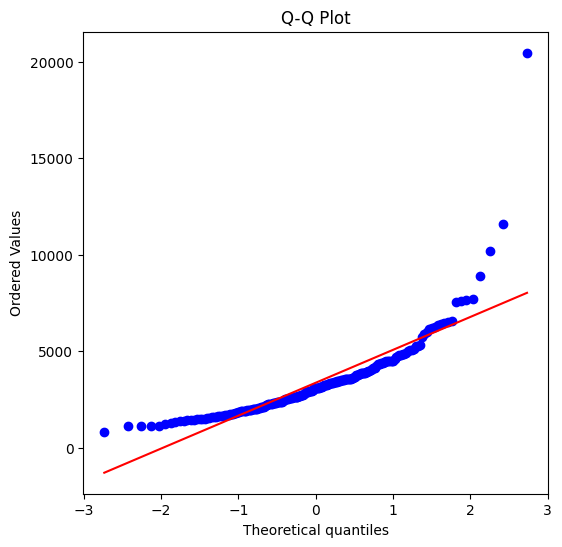

Sharpiro Statistics: 0.7360905663247675
P-Value: 1.9104194773842295e-18
Data is Not Normally Distributed.


In [28]:
plt.figure(figsize=(6,6))

stats.probplot(amt, dist="norm", plot=plt)

plt.title("Q-Q Plot")

plt.show()


# Shapiro-Wilk Test

stat, pvalue= stats.shapiro(amt)
print("Sharpiro Statistics:", stat)
print("P-Value:",pvalue)

if pvalue>0.05:
    print("Data appear Normally Distributed.")
else:
    print("Data is Not Normally Distributed.")
    

### Interpretation: 
- The Q-Q plot compares the dataset against a theoretical normal distribution. While values align with the diagonal line at lower and mid quantiles, the upward deviation at higher quantiles indicates heavier tails and right-skewness.
-  This suggests the data is not perfectly normal, with extreme values occurring more frequently than expected under a normal distribution.
 

# 5. Apply Box-Cox Transform to stabilize variance.

Optimal Lamda= -0.18123612911845818


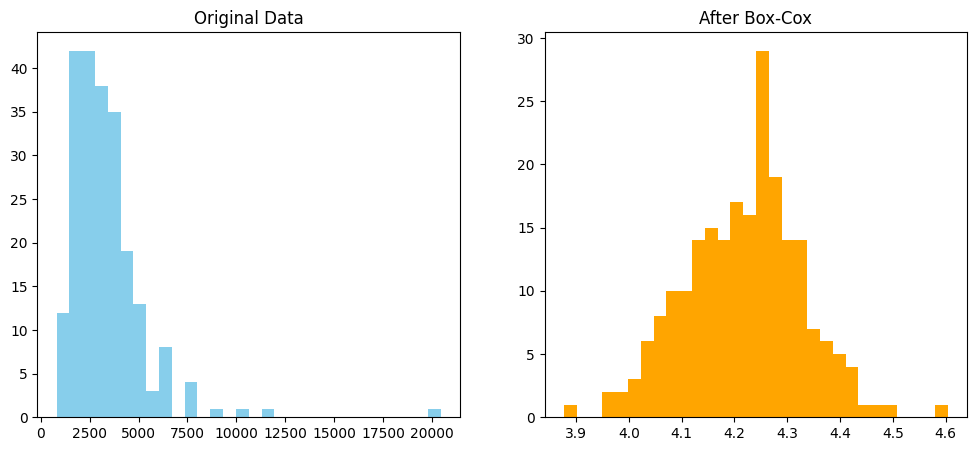


Analysis Completed Successfully


In [29]:
# Box-Cox requires positive values
positive= amt+1

transformed, lamda= stats.boxcox(positive)
print("Optimal Lamda=",lamda)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(amt, bins=30, color="skyblue")
plt.title("Original Data")

plt.subplot(1,2,2)
plt.hist(transformed, bins=30, color="orange")
plt.title("After Box-Cox")

plt.show()

print("\nAnalysis Completed Successfully")


### Interpretation:  
- The original data shows strong right-skewness, with most values concentrated at lower ranges and a long tail of larger values.
- After applying the Box-Cox transformation (λ ≈ -0.18), the distribution becomes more symmetric and approximately normal.
- This normalization improves suitability for statistical modeling and inference, reducing bias from skewed data.


# 6. Calculate Z-scores for transaction amounts and compute probability of transactions exceeding ₹5000.

In [35]:
# Calculate Z-Scores
data["Z-Score"] = zscore(amt)

print(data[["transaction_amount","Z-Score"]].head())

# Probability of transaction amount > ₹5000

mean=amt.mean()
std=amt.std()

prob= 1-norm.cdf(5000, loc=mean, scale=std)

print("Probability Of Transaction Amount > ₹5000:",prob)

   transaction_amount   Z-Score
0             3821.34  0.230240
1             2781.84 -0.294446
2             4120.97  0.381477
3             6383.78  1.523626
4             2651.61 -0.360179
Probability Of Transaction Amount > ₹5000: 0.20517209567554384


### Interpretation

- Z-Scores: Each transaction amount is standardized relative to the dataset’s mean and standard deviation. Positive Z-scores (e.g., 6383.78 → 1.52) indicate values above average, while negative ones (e.g., 2651.61 → -0.36) are below average.

- Probability result: The computed probability (≈ 0.205) means there’s about a 20.5% chance that a transaction exceeds ₹5000.

- Insight: Most transactions are moderate, but a significant portion (1 in 5) are large enough to cross the ₹5000 threshold, which could be important for risk or revenue analysis.

# 7. Plot and interpret PDF and CDF for transaction amounts.

## PDF

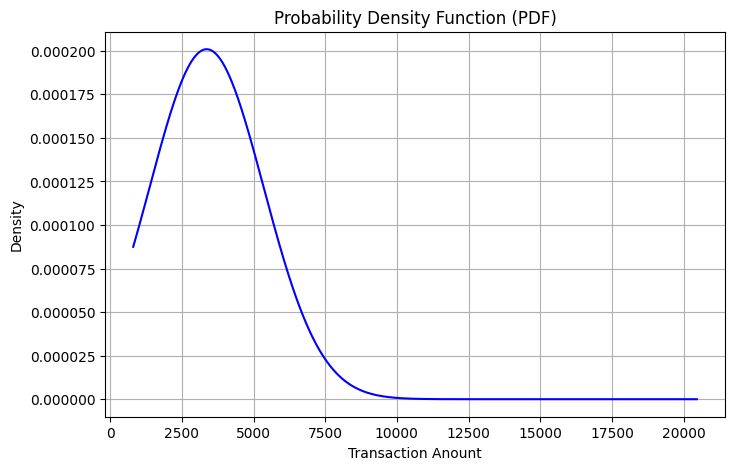

In [40]:
x= np.linspace(amt.min(), amt.max(), 500)
# PDF
pdf=norm.pdf(x,mean,std)

plt.figure(figsize=(8,5))
plt.plot(x, pdf, color="blue")
plt.title("Probability Density Function (PDF)")
plt.xlabel("Transaction Anount")
plt.ylabel("Density")
plt.grid(True)
plt.show()


### Interpretation
- Peak at lower values: The curve rises sharply around ₹3000, showing that smaller transaction amounts are the most common.

- Gradual decline: As transaction amounts increase, the density steadily decreases, meaning higher-value transactions occur less frequently.

- Distribution insight: This pattern reflects a positively skewed distribution — frequent small transactions with occasional large ones forming the long tail.

## CDF

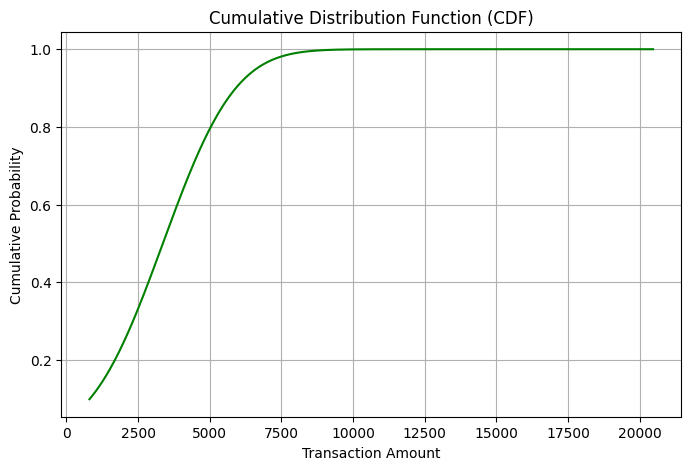

In [41]:
cdf= norm.cdf(x,mean,std)

plt.figure(figsize=(8,5))
plt.plot(x, cdf, color="green")
plt.title("Cumulative Distribution Function (CDF)")
plt.xlabel("Transaction Amount")
plt.ylabel("Cumulative Probability")
plt.grid(True)
plt.show()

### Interpretation
- Steep rise zone: The curve climbs quickly between ₹2000–₹7000, meaning most transactions fall within this range.

- Leveling off: After ₹7000, the curve flattens, showing that very few transactions occur at higher amounts.

- Overall insight: The CDF confirms that the majority of transactions are relatively small, with cumulative probability approaching 1 once amounts exceed ~₹7000–₹8000.

# 8. Conclude which distribution best fits the dataset and justify insights for decision-making.

In [43]:
# Log-Normal Fit
log_shape, log_loc, log_scale = lognorm.fit(amt, floc=0)
log_ll = lognorm.logpdf(amt, log_shape, log_loc, log_scale).sum()

# Power Law Fit
pow_shape, pow_loc, pow_scale = powerlaw.fit(amt)
pow_ll = powerlaw.logpdf(amt, pow_shape, pow_loc, pow_scale).sum()

print("Log-Normal Log-Likelihood:", log_ll)
print("Power Law Log-Likelihood:", pow_ll)

if log_ll > pow_ll:
    print("\nBest Fit: Log-Normal Distribution")
else:
    print("\nBest Fit: Power Law Distribution")

Log-Normal Log-Likelihood: -1908.5139027324365
Power Law Log-Likelihood: -2056.3239530711553

Best Fit: Log-Normal Distribution
